In [16]:
from data_loader import hourly_data_loader
df = hourly_data_loader()

print(f'Available Features:')
print(df.columns.to_list())

Available Features:
['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'hour', 'dayofweek', 'month', 'is_weekend', 'awake', 'evening', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_avg_12', 'rhum_lag3', 'prcp_sum_12', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'wdir_sin', 'wdir_cos']


In [17]:
FEATURE_COLS = [
    'temp',
    'rhum', 
    'prcp', 
    'wspd', 
    'wdir_sin',
    'wdir_cos',
    'temp_lag1', 
    'temp_lag3', 
    'temp_lag6',
    'temp_avg_12',
    'rhum_lag3',
    'prcp_sum_12',
    'awake',
    'is_weekend',
    'evening',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos'
    ]

TARGET_COL   = "kwh"

In [18]:
from sklearn.preprocessing import StandardScaler

# Sequential separation to prevent data leakage
X_data = df[FEATURE_COLS].values
y_data = df[TARGET_COL].values.reshape(-1, 1)  # Reshape required for scaling

split_idx = int(len(X_data) * 0.75)

scaler_X = StandardScaler()
scaler_X.fit(X_data[:split_idx])          # Learn the math from the past
X_scaled = scaler_X.transform(X_data)     # Apply the math to the whole timeline

scaler_y = StandardScaler()
scaler_y.fit(y_data[:split_idx])
y_scaled = scaler_y.transform(y_data)

X_train = X_scaled[:split_idx]
X_test  = X_scaled[split_idx:]
y_train = y_scaled[:split_idx]
y_test  = y_scaled[split_idx:]

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}  (mean={y_train.mean():.3f} kWh, std={y_train.std():.3f})")
print(f"y_test  shape: {y_test.shape}  (mean={y_test.mean():.3f} kWh, std={y_test.std():.3f})")

Features:      ['temp', 'rhum', 'prcp', 'wspd', 'wdir_sin', 'wdir_cos', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_avg_12', 'rhum_lag3', 'prcp_sum_12', 'awake', 'is_weekend', 'evening', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
X_train shape: (27637, 19)
X_test shape:  (9213, 19)
y_train shape: (27637, 1)  (mean=-0.000 kWh, std=1.000)
y_test  shape: (9213, 1)  (mean=0.240 kWh, std=1.084)


In [99]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Model
class MLP(nn.Module):
    def __init__(self, n_features, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),    # input layer: n_features → 12 neurons
            nn.ReLU(),                    # activation: zero out negatives
            nn.Dropout(dropout),             # randomly zero 5% of neurons during training (regularization)
            nn.Linear(64, 32),             # hidden layer
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)               # output layer
        )
    
    def forward(self, x):
        return self.net(x)              # forward pass: input flows through all layers sequentially


In [100]:
model = MLP(X_train_t.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.HuberLoss()

train_losses = []
test_losses = []

n_epochs = 25

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    
    #scheduler.step(test_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


Epoch   2 | Test MSE: 0.2776 | LR: 0.000100
Epoch   4 | Test MSE: 0.2627 | LR: 0.000100
Epoch   6 | Test MSE: 0.2540 | LR: 0.000100
Epoch   8 | Test MSE: 0.2545 | LR: 0.000100
Epoch  10 | Test MSE: 0.2505 | LR: 0.000100
Epoch  12 | Test MSE: 0.2523 | LR: 0.000100
Epoch  14 | Test MSE: 0.2472 | LR: 0.000100
Epoch  16 | Test MSE: 0.2465 | LR: 0.000100
Epoch  18 | Test MSE: 0.2429 | LR: 0.000100
Epoch  20 | Test MSE: 0.2466 | LR: 0.000100
Epoch  22 | Test MSE: 0.2434 | LR: 0.000100
Epoch  24 | Test MSE: 0.2461 | LR: 0.000100


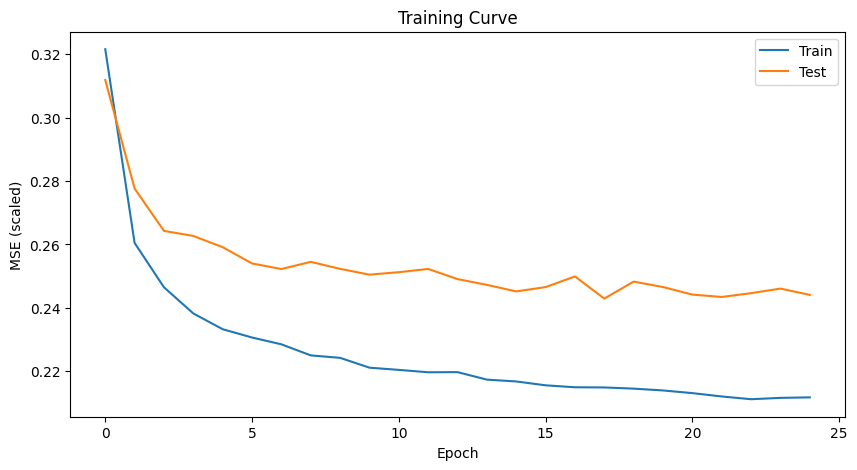

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Training Curve')
plt.show()

MLP: R²=0.512  RMSE=0.98 kWh  MAE=0.69 kWh


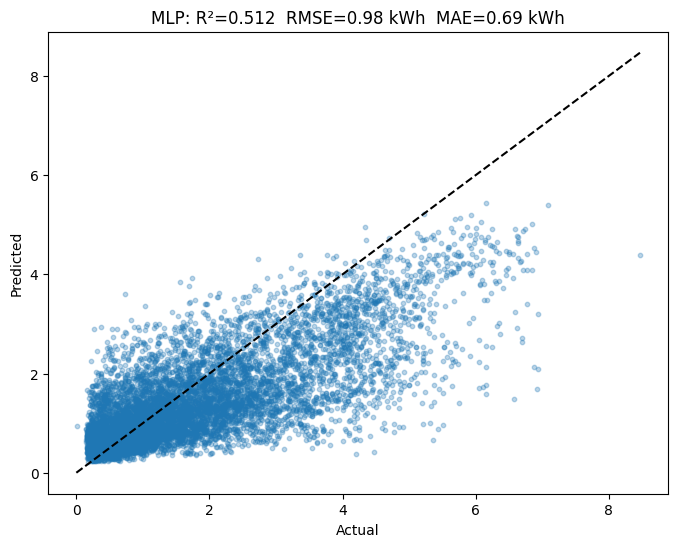

In [102]:
import numpy as np

model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()
    pred_kwh = scaler_y.inverse_transform(pred_scaled)
    test_kwh = scaler_y.inverse_transform(y_test)
    
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_kwh, pred_kwh))
r2 = r2_score(test_kwh, pred_kwh)
mae = mean_absolute_error(test_kwh, pred_kwh)

plt.figure(figsize=(8, 6))
plt.scatter(test_kwh, pred_kwh, alpha=0.3, s=10)
plt.plot([0, test_kwh.max()], [0, test_kwh.max()], 'k--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')

print(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh  MAE={mae:.2f} kWh')
plt.title(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh  MAE={mae:.2f} kWh')
plt.show()